## Credit Risk Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings("ignore")

---

## Exploratory Data Analysis (EDA)

- What does the data look like? (shape, dtypes)
- How balanced is the target variable? (how many defaults vs. non-defaults?)
- Are there missing values, and how bad are they?
- What do the feature distributions look like?

This will inform decisions to make in preprocessing and modeling

In [2]:
df = pd.read_csv("application_train.csv", index_col=0)

In [3]:
print(f"Rows: {df.shape[0]:,} \nColumns: {df.shape[1]}")
print(df.columns.sort_values().tolist())
print(df.head())

Rows: 307,511 
Columns: 121
['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'CODE_GENDER', 'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_REGISTRATION', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'EMERGENCYSTATE_MODE', 'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUME

In [4]:
print(df.dtypes.value_counts())

float64    65
int64      40
str        16
Name: count, dtype: int64


In [5]:
# Heavily imbalanced dataset. Will need to account for this later
print(df["TARGET"].value_counts())
print()
print(df["TARGET"].value_counts(normalize=True).round(4) *100)

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [6]:
# null values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

print(f"Columns WITH missing values: {len(missing_df)} out of {df.shape[1]}")
print()
print(missing_df.head(20))

Columns WITH missing values: 67 out of 121

                          Missing Count  Missing %
COMMONAREA_MEDI                  214865      69.87
COMMONAREA_MODE                  214865      69.87
COMMONAREA_AVG                   214865      69.87
NONLIVINGAPARTMENTS_MODE         213514      69.43
NONLIVINGAPARTMENTS_MEDI         213514      69.43
NONLIVINGAPARTMENTS_AVG          213514      69.43
FONDKAPREMONT_MODE               210295      68.39
LIVINGAPARTMENTS_AVG             210199      68.35
LIVINGAPARTMENTS_MEDI            210199      68.35
LIVINGAPARTMENTS_MODE            210199      68.35
FLOORSMIN_MEDI                   208642      67.85
FLOORSMIN_MODE                   208642      67.85
FLOORSMIN_AVG                    208642      67.85
YEARS_BUILD_MODE                 204488      66.50
YEARS_BUILD_MEDI                 204488      66.50
YEARS_BUILD_AVG                  204488      66.50
OWN_CAR_AGE                      202929      65.99
LANDAREA_AVG                     18259

In [7]:
# what percentage threshold to drop at?
MISSING_THRESHOLD = 40

cols_to_drop = missing_df[missing_df["Missing %"] > MISSING_THRESHOLD].index.tolist()

print(f"Columns with more than {MISSING_THRESHOLD}% missing: {len(cols_to_drop)}")
print()
print(cols_to_drop)

Columns with more than 40% missing: 49

['COMMONAREA_MEDI', 'COMMONAREA_MODE', 'COMMONAREA_AVG', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE', 'FLOORSMIN_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'EXT_SOURCE_1', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MODE', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'ELEVATORS_AVG', 'WALLSMATERIAL_MODE', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'ENTRANCES_MODE', 'ENTRANCES_MEDI', 'ENTRANCES_AVG', 'LIVINGAREA_AVG', 'LIVINGAREA_MODE', 'LIVINGAREA_MEDI', 'HOUSETYPE_MODE', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG'

In [8]:
df = df.drop(columns=cols_to_drop)

print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 72


In [9]:
# All columns that were scaled by Home Credit were removed
# Find columns that have AVG, MEDI, or MODE suffix
avg_cols = [col for col in df.columns if col.endswith("_AVG")]
medi_cols = [col for col in df.columns if col.endswith("_MEDI")]
mode_cols = [col for col in df.columns if col.endswith("_MODE")]

print(f"Remaining AVG columns:  {len(avg_cols)}")
print(f"Remaining MEDI columns: {len(medi_cols)}")
print(f"Remaining MODE columns: {len(mode_cols)}")
print("AVG columns:", avg_cols)

Remaining AVG columns:  0
Remaining MEDI columns: 0
Remaining MODE columns: 0
AVG columns: []


### Progress update
- Started with 121 columns
- Dropped 49 for exceeding 40% missingness
- AVG/MEDI/MODE columns all gone as a result. These were cols that were pre-scaled by Home Credit
- 72 columns remaining

In [10]:
for i, col in enumerate(df.columns.tolist()):
    print(f"{i+1:>3}. {col}")

  1. TARGET
  2. NAME_CONTRACT_TYPE
  3. CODE_GENDER
  4. FLAG_OWN_CAR
  5. FLAG_OWN_REALTY
  6. CNT_CHILDREN
  7. AMT_INCOME_TOTAL
  8. AMT_CREDIT
  9. AMT_ANNUITY
 10. AMT_GOODS_PRICE
 11. NAME_TYPE_SUITE
 12. NAME_INCOME_TYPE
 13. NAME_EDUCATION_TYPE
 14. NAME_FAMILY_STATUS
 15. NAME_HOUSING_TYPE
 16. REGION_POPULATION_RELATIVE
 17. DAYS_BIRTH
 18. DAYS_EMPLOYED
 19. DAYS_REGISTRATION
 20. DAYS_ID_PUBLISH
 21. FLAG_MOBIL
 22. FLAG_EMP_PHONE
 23. FLAG_WORK_PHONE
 24. FLAG_CONT_MOBILE
 25. FLAG_PHONE
 26. FLAG_EMAIL
 27. OCCUPATION_TYPE
 28. CNT_FAM_MEMBERS
 29. REGION_RATING_CLIENT
 30. REGION_RATING_CLIENT_W_CITY
 31. WEEKDAY_APPR_PROCESS_START
 32. HOUR_APPR_PROCESS_START
 33. REG_REGION_NOT_LIVE_REGION
 34. REG_REGION_NOT_WORK_REGION
 35. LIVE_REGION_NOT_WORK_REGION
 36. REG_CITY_NOT_LIVE_CITY
 37. REG_CITY_NOT_WORK_CITY
 38. LIVE_CITY_NOT_WORK_CITY
 39. ORGANIZATION_TYPE
 40. EXT_SOURCE_2
 41. EXT_SOURCE_3
 42. OBS_30_CNT_SOCIAL_CIRCLE
 43. DEF_30_CNT_SOCIAL_CIRCLE
 44. OBS_60_CN

In [11]:
# Jumpinng ahead just a bit to create 2 easier-to-interpret features
# Instead of days since birth, use age. Instead of years employed, use days
df["AGE_YEARS"] = df["DAYS_BIRTH"].abs() / 365
df["YEARS_EMPLOYED"] = df["DAYS_EMPLOYED"].abs() / 365

### Feature Assessment Summary

After reviewing all 72 remaining columns, features were categorized into three groups based on their expected predictive power:

**Strong Predictors (keep and prioritize):**
- `EXT_SOURCE_2` & `EXT_SOURCE_3` — external credit scores from third party bureaus,
  typically the strongest predictors in credit risk models
- `DAYS_BIRTH` — applicant age stored as negative days, needs engineering to convert to years
- `DAYS_EMPLOYED` — employment length stored as negative days, needs engineering
- `AMT_INCOME_TOTAL` — total annual income
- `AMT_CREDIT` — loan amount requested
- `AMT_ANNUITY` — monthly repayment amount, useful alongside income to assess affordability
- `REGION_RATING_CLIENT` — Home Credit's internal region risk rating

**Potentially Useful (keep for now, let model decide):**
- `NAME_EDUCATION_TYPE`, `NAME_INCOME_TYPE`, `NAME_FAMILY_STATUS` — demographic
  categoricals that correlate with financial stability
- `DEF_30_CNT_SOCIAL_CIRCLE` & `DEF_60_CNT_SOCIAL_CIRCLE` — defaults in applicant's
  social circle, a unique behavioral signal
- `AMT_REQ_CREDIT_BUREAU_YEAR` — credit inquiries in the past year, too many can
  signal financial desperation

**Likely Noise (probably drop):**
- `FLAG_DOCUMENT_2` through `FLAG_DOCUMENT_21` — document submission flags,
  likely near-zero variance
- `FLAG_MOBIL`, `FLAG_EMP_PHONE` etc — contact flags, likely low variance
- `WEEKDAY_APPR_PROCESS_START`, `HOUR_APPR_PROCESS_START` — application timing,
  probably not predictive

**Features Engineered:**
- `DAYS_BIRTH` → convert to `AGE_YEARS` (divide absolute value by 365)
- `DAYS_EMPLOYED` → convert to `YEARS_EMPLOYED` (divide absolute value by 365)

**Key Things Covered:**
- **Class imbalance** — 91.93% non-default vs 8.07% default means accuracy is a misleading metric. Will use ROC-AUC instead
- **MNAR missingness** — missing data in this dataset does not seem random. The fact that data is missing can itself be a signal
- **Multicollinearity** — highly correlated columns add noise without adding information. Dropped AVG/MEDI/MODE duplicates and will consolidate similar features later

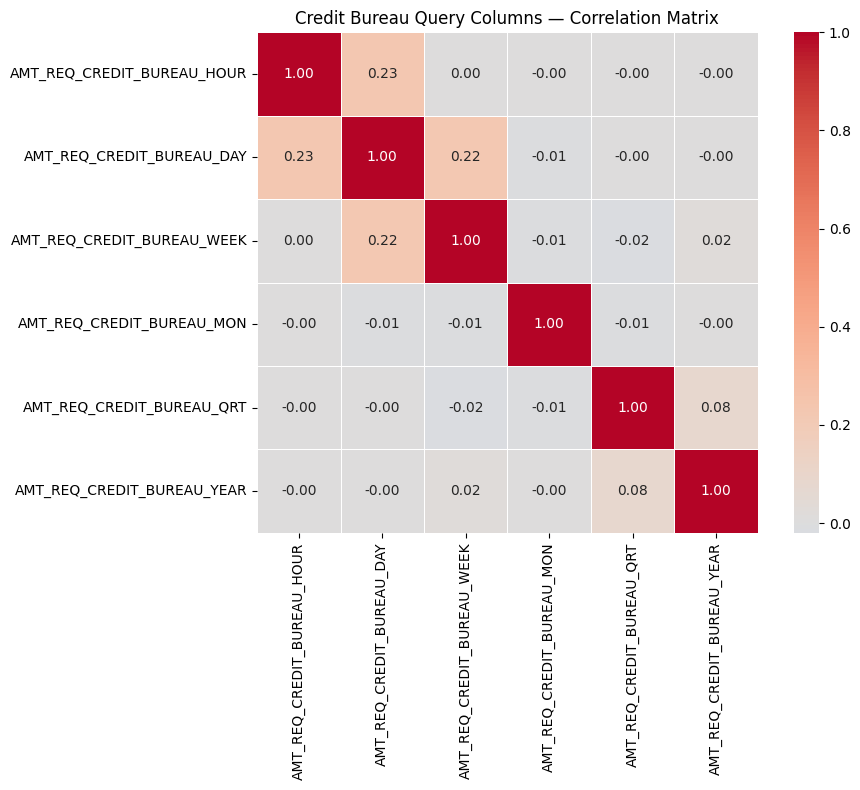

In [12]:
# Values are not correlated, so earlier thought to drop all but 1 because of redundant information is not true. Keep all fields for now
bureau_cols = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

corr_matrix = df[bureau_cols].corr().round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Credit Bureau Query Columns — Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
# Check for correlation across numeric cols
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")

corr_matrix_full = df[numerical_cols].corr().abs()

# Find pairs with correlation above 0.8
high_corr_pairs = []

for i in range(len(corr_matrix_full.columns)):
    for j in range(i + 1, len(corr_matrix_full.columns)):
        if corr_matrix_full.iloc[i, j] > 0.8:
            high_corr_pairs.append({
                "Feature 1": corr_matrix_full.columns[i],
                "Feature 2": corr_matrix_full.columns[j],
                "Correlation": corr_matrix_full.iloc[i, j].round(3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("Correlation", ascending=False)
print(f"\nHighly correlated pairs (above 0.8): {len(high_corr_df)}")
print()
print(high_corr_df.to_string(index=False))

Numerical columns: 62

Highly correlated pairs (above 0.8): 11

                 Feature 1                   Feature 2  Correlation
                DAYS_BIRTH                   AGE_YEARS        1.000
             DAYS_EMPLOYED              YEARS_EMPLOYED        1.000
             DAYS_EMPLOYED              FLAG_EMP_PHONE        1.000
            FLAG_EMP_PHONE              YEARS_EMPLOYED        1.000
  OBS_30_CNT_SOCIAL_CIRCLE    OBS_60_CNT_SOCIAL_CIRCLE        0.998
                AMT_CREDIT             AMT_GOODS_PRICE        0.987
      REGION_RATING_CLIENT REGION_RATING_CLIENT_W_CITY        0.951
              CNT_CHILDREN             CNT_FAM_MEMBERS        0.879
REG_REGION_NOT_WORK_REGION LIVE_REGION_NOT_WORK_REGION        0.861
  DEF_30_CNT_SOCIAL_CIRCLE    DEF_60_CNT_SOCIAL_CIRCLE        0.861
    REG_CITY_NOT_WORK_CITY     LIVE_CITY_NOT_WORK_CITY        0.826


In [14]:
# DAYS_EMPLOYED and FLAG_EMP_PHONE is a strange correlation
# 365243 days is around 1000 years. This is most likely a fake value to represent unemployed
# this explains the correlation. unemployed people don't have a work phone, so FLAG_EMP_PHONE=0 aligns with DAYS_EMPLOYED=365243
print(df["DAYS_EMPLOYED"].value_counts().head(5))

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64


In [15]:
# replace with nan for now
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

# Verify it's gone
print(f"Sentinel values remaining: {(df['DAYS_EMPLOYED'] == 365243).sum()}")
print(f"Missing values in DAYS_EMPLOYED: {df['DAYS_EMPLOYED'].isnull().sum()}")

Sentinel values remaining: 0
Missing values in DAYS_EMPLOYED: 55374


### Data Quality & Correlation Analysis Summary

**Dummy Value Discovery:**
Discovered that `DAYS_EMPLOYED` contained a dummy 
value of 365,243 (roughly 1,000 years) for 55,374 applicants (~18% of the dataset). 
This is a placeholder used to represent unemployed applicants. Big data quality issue because:
- It doesn't appear in standard missing value checks
- The model would treat it as a real number, completely distorting predictions
- Replaced all instances with `NaN` so it is handled correctly in preprocessing

**Correlation Analysis:**
Computed pairwise correlations across all 62 numerical columns and identified 
11 highly correlated pairs (above 0.8 threshold). For each pair, kept the more 
meaningful or interpretable feature and dropped the redundant one:

| Dropped Feature | Kept Feature | Reason |
|---|---|---|
| `DAYS_BIRTH` | `AGE_YEARS` | Engineered version is more interpretable |
| `DAYS_EMPLOYED` | `YEARS_EMPLOYED` | Engineered version is more interpretable |
| `FLAG_EMP_PHONE` | `YEARS_EMPLOYED` | Just a proxy for unemployment, already captured |
| `OBS_30_CNT_SOCIAL_CIRCLE` | `OBS_60_CNT_SOCIAL_CIRCLE` | Longer window more informative |
| `AMT_GOODS_PRICE` | `AMT_CREDIT` | Loan amount more directly relevant to default risk |
| `REGION_RATING_CLIENT` | `REGION_RATING_CLIENT_W_CITY` | City-adjusted version more granular |
| `CNT_CHILDREN` | `CNT_FAM_MEMBERS` | Family members is a broader picture |
| `REG_REGION_NOT_WORK_REGION` | `LIVE_REGION_NOT_WORK_REGION` | Actual residence vs work more meaningful than registration |
| `DEF_30_CNT_SOCIAL_CIRCLE` | `DEF_60_CNT_SOCIAL_CIRCLE` | Longer window more informative |
| `REG_CITY_NOT_WORK_CITY` | `LIVE_CITY_NOT_WORK_CITY` | Actual city vs work more meaningful than registration |

Keeping highly correlated features adds noise without adding information, and can also make model interpretation harder because the model splits importance between two columns that are essentially saying the same thing. Removing redundant features keeps the model clean and interpretable

In [16]:
cols_to_drop_corr = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "FLAG_EMP_PHONE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "AMT_GOODS_PRICE",
    "REGION_RATING_CLIENT",
    "CNT_CHILDREN",
    "REG_REGION_NOT_WORK_REGION",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "REG_CITY_NOT_WORK_CITY"
]

df = df.drop(columns=cols_to_drop_corr)

print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 64


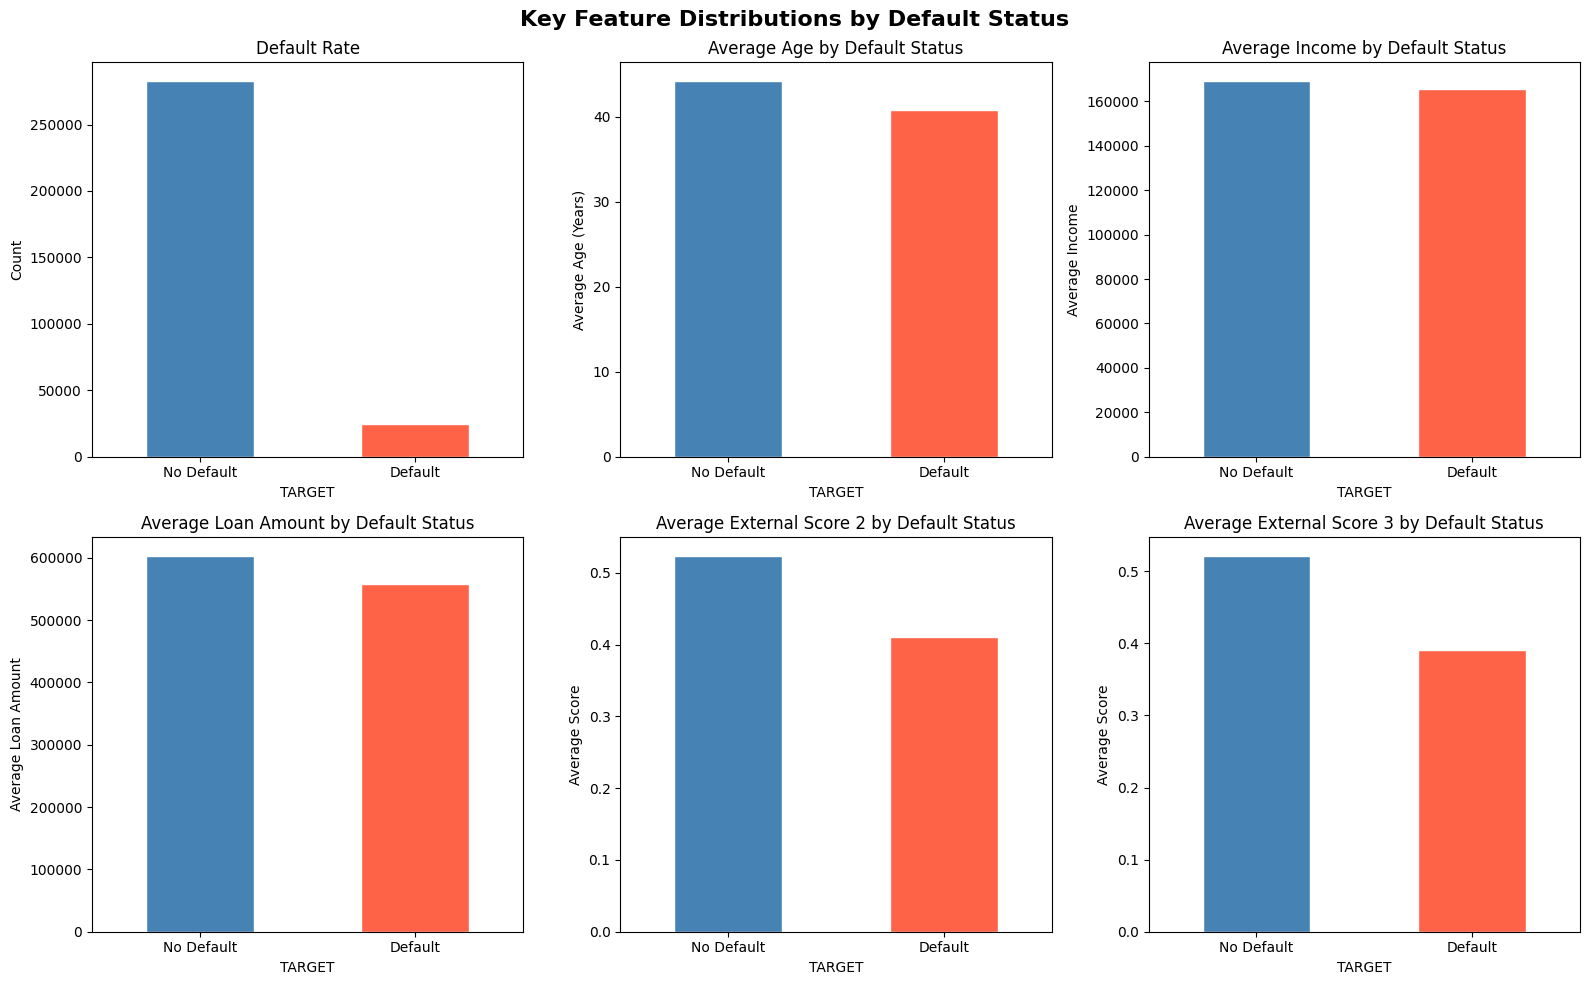

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Key Feature Distributions by Default Status", fontsize=16, fontweight="bold")

# 1. Default rate
df["TARGET"].value_counts().plot(
    kind="bar",
    ax=axes[0, 0],
    color=["steelblue", "tomato"],
    edgecolor="white"
)
axes[0, 0].set_title("Default Rate")
axes[0, 0].set_xticklabels(["No Default", "Default"], rotation=0)
axes[0, 0].set_ylabel("Count")

# 2. Age by default status
df.groupby("TARGET")["AGE_YEARS"].mean().plot(
    kind="bar",
    ax=axes[0, 1],
    color=["steelblue", "tomato"],
    edgecolor="white"
)
axes[0, 1].set_title("Average Age by Default Status")
axes[0, 1].set_xticklabels(["No Default", "Default"], rotation=0)
axes[0, 1].set_ylabel("Average Age (Years)")

# 3. Income by default status
df.groupby("TARGET")["AMT_INCOME_TOTAL"].mean().plot(
    kind="bar",
    ax=axes[0, 2],
    color=["steelblue", "tomato"],
    edgecolor="white"
)
axes[0, 2].set_title("Average Income by Default Status")
axes[0, 2].set_xticklabels(["No Default", "Default"], rotation=0)
axes[0, 2].set_ylabel("Average Income")

# 4. Credit amount by default status
df.groupby("TARGET")["AMT_CREDIT"].mean().plot(
    kind="bar",
    ax=axes[1, 0],
    color=["steelblue", "tomato"],
    edgecolor="white"
)
axes[1, 0].set_title("Average Loan Amount by Default Status")
axes[1, 0].set_xticklabels(["No Default", "Default"], rotation=0)
axes[1, 0].set_ylabel("Average Loan Amount")

# 5. External source 2 by default status
df.groupby("TARGET")["EXT_SOURCE_2"].mean().plot(
    kind="bar",
    ax=axes[1, 1],
    color=["steelblue", "tomato"],
    edgecolor="white"
)
axes[1, 1].set_title("Average External Score 2 by Default Status")
axes[1, 1].set_xticklabels(["No Default", "Default"], rotation=0)
axes[1, 1].set_ylabel("Average Score")

# 6. External source 3 by default status
df.groupby("TARGET")["EXT_SOURCE_3"].mean().plot(
    kind="bar",
    ax=axes[1, 2],
    color=["steelblue", "tomato"],
    edgecolor="white"
)
axes[1, 2].set_title("Average External Score 3 by Default Status")
axes[1, 2].set_xticklabels(["No Default", "Default"], rotation=0)
axes[1, 2].set_ylabel("Average Score")

plt.tight_layout()
plt.savefig("eda_key_features.png", dpi=150)
plt.show()

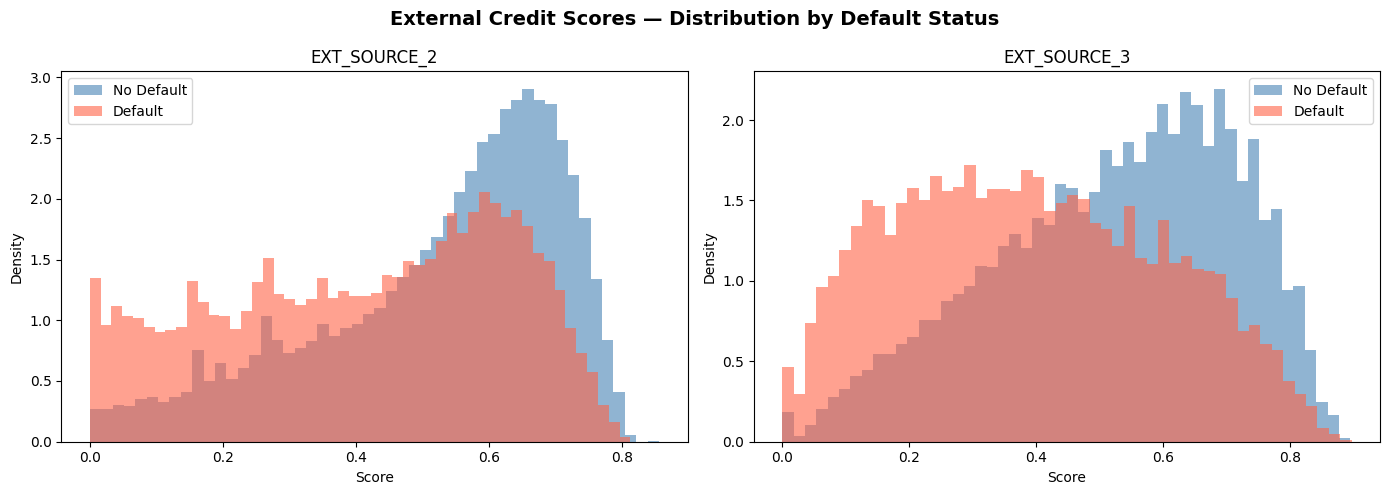

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("External Credit Scores — Distribution by Default Status", fontsize=14, fontweight="bold")

for i, col in enumerate(["EXT_SOURCE_2", "EXT_SOURCE_3"]):
    df[df["TARGET"] == 0][col].dropna().plot(
        kind="hist",
        bins=50,
        ax=axes[i],
        alpha=0.6,
        color="steelblue",
        label="No Default",
        density=True
    )
    df[df["TARGET"] == 1][col].dropna().plot(
        kind="hist",
        bins=50,
        ax=axes[i],
        alpha=0.6,
        color="tomato",
        label="Default",
        density=True
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.tight_layout()
plt.savefig("ext_source_distributions.png", dpi=150)
plt.show()

### End of EDA Key Takeaways

- Dataset contains 307,511 loan applications with 64 features after cleaning
- Strong class imbalance — 91.93% non-default vs 8.07% default, meaning accuracy
  is a misleading metric. We will use ROC-AUC instead
- 67 columns had missing values, 49 were dropped for exceeding 40% missingness threshold
- A dummy value of 365,243 was discovered in `DAYS_EMPLOYED` representing unemployed
  applicants — replaced with NaN before modeling
- 10 redundant columns were dropped after correlation analysis
- `EXT_SOURCE_2` and `EXT_SOURCE_3` showed clear distributional separation between
  defaulters and non-defaulters, suggesting they will be strong predictors

**Going into preprocessing:**
- 64 columns, down from 121
- Solid understanding of which features are likely to matter
- Known missing value locations that need to be handled before modeling
- Categorical columns that need to be converted to numbers

---

## Preprocessing:
1. **Handle remaining missing values** — impute or drop remaining nulls
2. **Encode categorical variables** — convert text columns to numbers
3. **Feature engineering** — create meaningful features from existing ones
4. **Scale numerical features** — normalize ranges so no single feature dominates

In [23]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

remaining_missing = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

remaining_missing = remaining_missing[remaining_missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)

print(f"Columns with missing values: {len(remaining_missing)}")
print()
print(remaining_missing)

Columns with missing values: 15

                            Missing Count  Missing %
OCCUPATION_TYPE                     96391      31.35
EXT_SOURCE_3                        60965      19.83
AMT_REQ_CREDIT_BUREAU_QRT           41519      13.50
AMT_REQ_CREDIT_BUREAU_WEEK          41519      13.50
AMT_REQ_CREDIT_BUREAU_MON           41519      13.50
AMT_REQ_CREDIT_BUREAU_HOUR          41519      13.50
AMT_REQ_CREDIT_BUREAU_DAY           41519      13.50
AMT_REQ_CREDIT_BUREAU_YEAR          41519      13.50
NAME_TYPE_SUITE                      1292       0.42
DEF_60_CNT_SOCIAL_CIRCLE             1021       0.33
OBS_60_CNT_SOCIAL_CIRCLE             1021       0.33
EXT_SOURCE_2                          660       0.21
AMT_ANNUITY                            12       0.00
CNT_FAM_MEMBERS                         2       0.00
DAYS_LAST_PHONE_CHANGE                  1       0.00


In [33]:
# Group 1 — High missingness
df["OCCUPATION_TYPE"] = df["OCCUPATION_TYPE"].fillna("Unknown")
# OCCUPATION_TYPE=Unknown are probably unemployed applicants, but for now just leave as Unknown
# Leave EXT_SOURCE_3 as nan — XGBoost handles it natively

# Group 2 — Bureau query columns, missing means no credit history
bureau_cols = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]
df[bureau_cols] = df[bureau_cols].fillna(0)

# Group 3 — Low missingness
# Numerical — fill with median
num_tiny = ["DEF_60_CNT_SOCIAL_CIRCLE", "OBS_60_CNT_SOCIAL_CIRCLE",
            "EXT_SOURCE_2", "AMT_ANNUITY", "CNT_FAM_MEMBERS", 
            "DAYS_LAST_PHONE_CHANGE"]
for col in num_tiny:
    df[col] = df[col].fillna(df[col].median())

# Categorical — fill with mode
df["NAME_TYPE_SUITE"] = df["NAME_TYPE_SUITE"].fillna(df["NAME_TYPE_SUITE"].mode()[0])

# Verify no missing values remain except EXT_SOURCE_3
remaining = df.isnull().sum()
print(f'Remaining Missing Value Counts: {remaining[remaining > 0]}')

Remaining Missing Value Counts: EXT_SOURCE_3    60965
dtype: int64


### Missing Value Imputation Summary

Handled the 15 remaining columns with missing values using four different 
strategies, chosen based on the nature of each column and its missingness:

**Left as NaN — XGBoost native handling:**
- `EXT_SOURCE_3` (19.83% missing) — one of the strongest predictors. Rather than risk introducing bias through imputation, leave it as NaN and allow XGBoost to handle it during training. XGBoost learns the optimal direction for missing values at each split, making this the safest choice for important features

**Filled with 0 — Missing means none:**
- All 6 `AMT_REQ_CREDIT_BUREAU_*` columns (13.50% missing) — missing values here
  almost certainly represent applicants with no credit history,
  making 0 the meaningful interpretation instead of a guess

**Filled with Unknown — Categorical, reason unclear:**
- `OCCUPATION_TYPE` (31.35% missing) — likely represents unemployed applicants
  but can't be certain. Rather than assume, label as Unknown. The model can learn patterns from this category, and the missingness itself may be an informative signal worth investigating further

**Filled with median — Numerical, tiny missingness:**
- `DEF_60_CNT_SOCIAL_CIRCLE`, `OBS_60_CNT_SOCIAL_CIRCLE`, `EXT_SOURCE_2`,
  `AMT_ANNUITY`, `CNT_FAM_MEMBERS`, `DAYS_LAST_PHONE_CHANGE` (all under 1%)
  — median is better at handling outliers and with less than 1% missing the imputation
  choice has negligible impact on model performance

**Filled with mode — Categorical, tiny missingness:**
- `NAME_TYPE_SUITE` (0.42% missing) — most common category is a safe neutral
  assumption when missingness is this small

In [36]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Categorical columns: {len(cat_cols)}")
print()
for col in cat_cols:
    print(f"{col:<30} unique values: {df[col].nunique()}")

Categorical columns: 12

NAME_CONTRACT_TYPE             unique values: 2
CODE_GENDER                    unique values: 3
FLAG_OWN_CAR                   unique values: 2
FLAG_OWN_REALTY                unique values: 2
NAME_TYPE_SUITE                unique values: 7
NAME_INCOME_TYPE               unique values: 8
NAME_EDUCATION_TYPE            unique values: 5
NAME_FAMILY_STATUS             unique values: 6
NAME_HOUSING_TYPE              unique values: 6
OCCUPATION_TYPE                unique values: 19
WEEKDAY_APPR_PROCESS_START     unique values: 7
ORGANIZATION_TYPE              unique values: 58


### Categorical Encoding Decisions

**Label Encoded** (replaced with a single integer):
- **`NAME_CONTRACT_TYPE`** — binary column with only 2 values, no false ordering issue
- **`FLAG_OWN_CAR`** — binary Y/N, label encoding is sufficient
- **`FLAG_OWN_REALTY`** — binary Y/N, label encoding is sufficient
- **`OCCUPATION_TYPE`** — somewhat high cardinality (19 values), one hot encoding would
  create too many columns and XGBoost handles label encoded categoricals well
- **`WEEKDAY_APPR_PROCESS_START`** — days of the week have a natural order
- **`ORGANIZATION_TYPE`** — high cardinality (58 unique values), one hot encoding
  would bloat the dataset unnecessarily

**One Hot Encoded** (created a new binary column for each unique value)(all low cardinality):
- **`NAME_TYPE_SUITE`** (7 values), each category is distinct with no natural ordering
- **`NAME_INCOME_TYPE`** (8 values), income type categories are distinct and important for risk assessment
- **`NAME_EDUCATION_TYPE`** (5 values), education levels are distinct categories with no true numeric ordering
- **`NAME_FAMILY_STATUS`** (6 values), family status categories are distinct with no natural ordering
- **`NAME_HOUSING_TYPE`** (6 values), housing type categories are distinct with no natural ordering

In [38]:
# Will drop gender from df. Even though it may have predictive power, the model should assess creditworthiness based on financial behavior,
# not demographics. Using gender seems like an ethical issue
df['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [39]:
from sklearn.preprocessing import LabelEncoder

# Drop gender for ethical and legal reasons
df = df.drop(columns=["CODE_GENDER"])

# Label encode binary and high cardinality columns
label_encode_cols = [
    "NAME_CONTRACT_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "OCCUPATION_TYPE",
    "WEEKDAY_APPR_PROCESS_START",
    "ORGANIZATION_TYPE"
]

le = LabelEncoder()
for col in label_encode_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# One hot encode low cardinality columns
one_hot_cols = [
    "NAME_TYPE_SUITE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]

df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

print(f"Columns after encoding: {df.shape[1]}")
print(f"Rows after encoding: {df.shape[0]:,}")

# Verify no categorical columns remain
remaining_cat = df.select_dtypes(include=["object"]).columns.tolist()
print(f"\nRemaining categorical columns: {remaining_cat}")

Columns after encoding: 85
Rows after encoding: 307,511

Remaining categorical columns: []


In [45]:
# Convert boolean columns to integer
bool_cols = df.select_dtypes(include="bool").columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

# Verify
print("dtypes breakdown after fix:")
print(df.dtypes.value_counts())

dtypes breakdown after fix:
int64      66
float64    19
Name: count, dtype: int64


## Final data check

In [49]:
# check for highly correlated features again
corr_matrix = df.corr().abs()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8:
            high_corr_pairs.append({
                "Feature 1": corr_matrix.columns[i],
                "Feature 2": corr_matrix.columns[j],
                "Correlation": corr_matrix.iloc[i, j].round(3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("Correlation", ascending=False)
print(f"Highly correlated pairs (above 0.8): {len(high_corr_df)}")
print()
print(high_corr_df.to_string(index=False))

Highly correlated pairs (above 0.8): 3

                           Feature 1                                         Feature 2  Correlation
                      YEARS_EMPLOYED                        NAME_INCOME_TYPE_Pensioner        1.000
NAME_EDUCATION_TYPE_Higher education NAME_EDUCATION_TYPE_Secondary / secondary special        0.888
              NAME_TYPE_SUITE_Family                     NAME_TYPE_SUITE_Unaccompanied        0.806


In [75]:
# Redundant info dropped (pensioners are retired and no longer work)
df = df.drop(columns=["NAME_INCOME_TYPE_Pensioner"])

print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 84


In [80]:
# Replace any value over 100 years employed with NaN
df["YEARS_EMPLOYED"] = df["YEARS_EMPLOYED"].where(df["YEARS_EMPLOYED"] <= 100, np.nan)

# Verify
print(df["YEARS_EMPLOYED"].describe())
df['YEARS_EMPLOYED'].isnull().sum()

count    252137.000000
mean          6.531971
std           6.406466
min           0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: YEARS_EMPLOYED, dtype: float64


np.int64(55374)

In [83]:
# Select continuous numerical columns only
plot_cols = [col for col in df.columns 
             if df[col].nunique() > 10]

print(f"Columns to plot: {len(plot_cols)}")
print(plot_cols)

Columns to plot: 19
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'REGION_POPULATION_RELATIVE', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'HOUR_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'AGE_YEARS', 'YEARS_EMPLOYED']


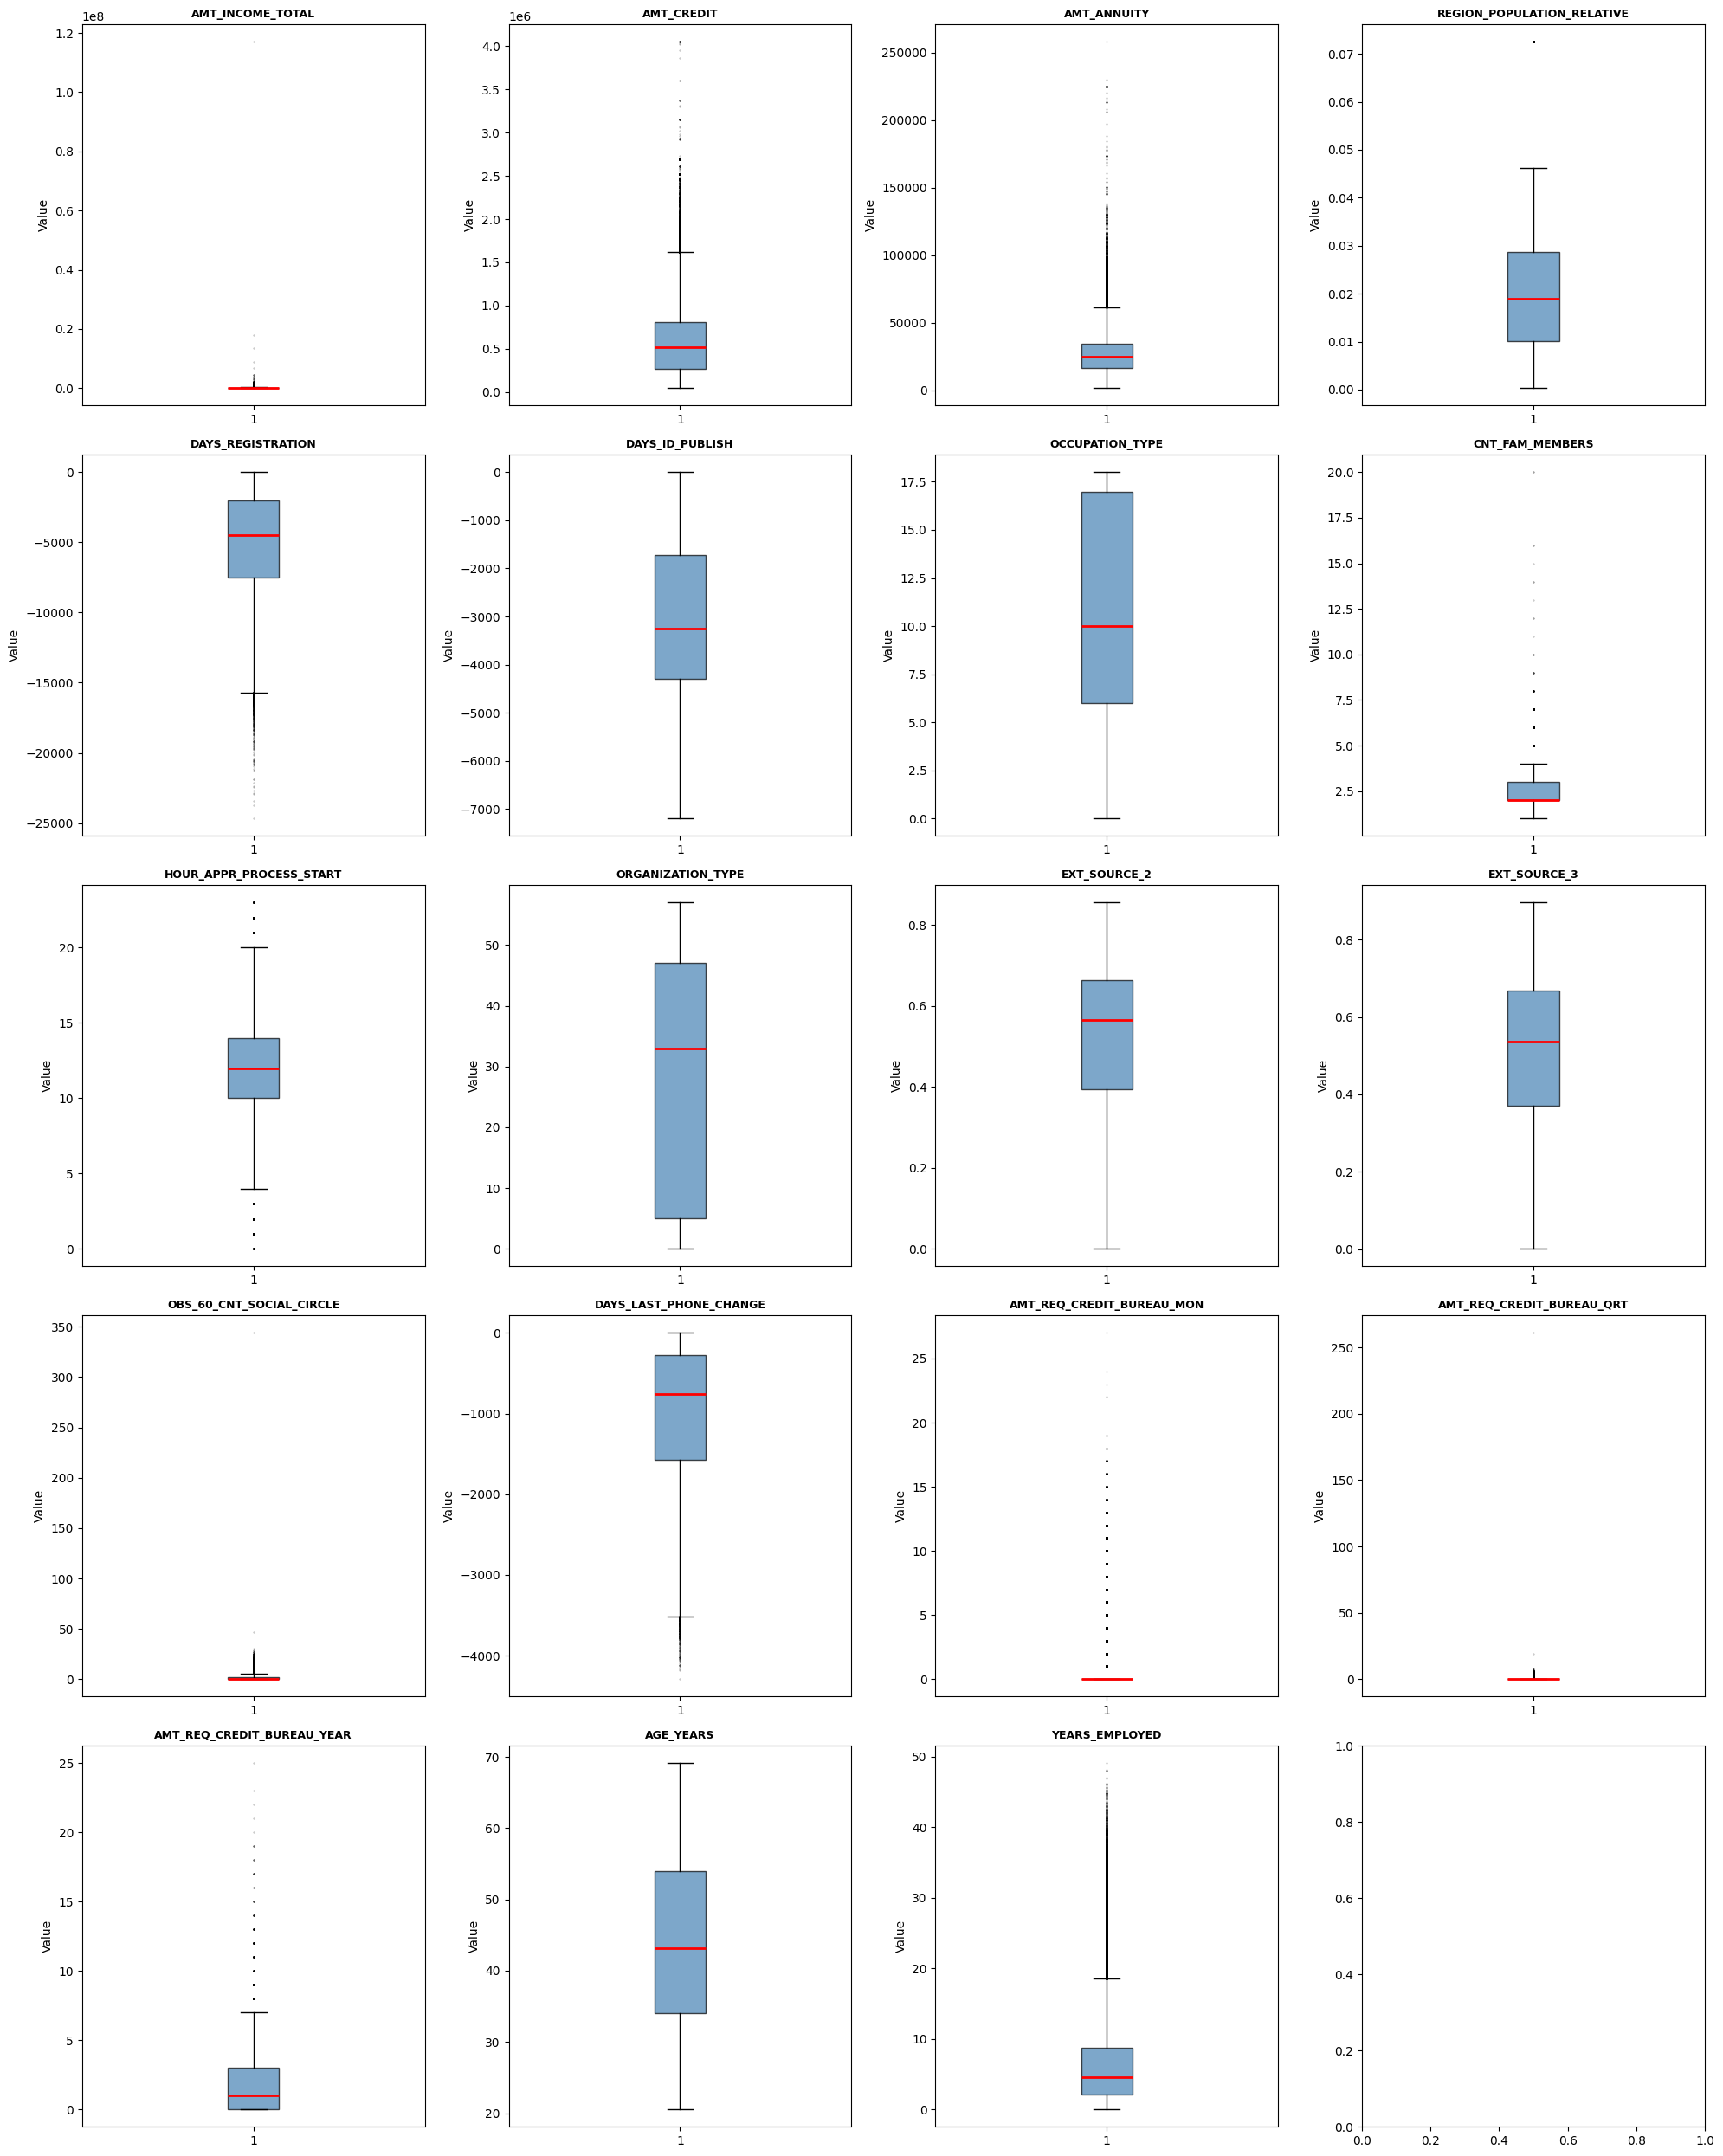

In [85]:
# check distributions
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()
b
for i, col in enumerate(plot_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2),
                    flierprops=dict(marker=".", markersize=1, alpha=0.3))
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.savefig("boxplots.png", dpi=150)
plt.show()

In [92]:
# handle extreme outliers
outlier_summary = []

for col in plot_cols:
    col_data = df[col].dropna()
    p99 = col_data.quantile(0.99)
    p999 = col_data.quantile(0.999)
    max_val = col_data.max()
    
    # How many times larger is the max vs 99th percentile?
    ratio = max_val / p99 if p99 != 0 else 0
    
    outlier_summary.append({
        "Column": col,
        "Median": col_data.median().round(2),
        "99th Pct": p99.round(2),
        "99.9th Pct": p999.round(2),
        "Max": max_val.round(2),
        "Max/99th Ratio": ratio
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("Max/99th Ratio", ascending=False)
print(outlier_df.to_string(index=False))

                    Column    Median   99th Pct  99.9th Pct          Max  Max/99th Ratio
          AMT_INCOME_TOTAL 147150.00  472500.00   900000.00 117000000.00      247.619048
 AMT_REQ_CREDIT_BUREAU_QRT      0.00       2.00        4.00       261.00      130.500000
  OBS_60_CNT_SOCIAL_CIRCLE      0.00      10.00       16.00       344.00       34.400000
 AMT_REQ_CREDIT_BUREAU_MON      0.00       4.00       11.00        27.00        6.750000
           CNT_FAM_MEMBERS      2.00       5.00        6.00        20.00        4.000000
               AMT_ANNUITY  24903.00   70006.50   110047.50    258025.50        3.685736
AMT_REQ_CREDIT_BUREAU_YEAR      1.00       8.00        9.00        25.00        3.125000
                AMT_CREDIT 513531.00 1854000.00  2517300.00   4050000.00        2.184466
            YEARS_EMPLOYED      4.52      31.06       39.79        49.07        1.579781
   HOUR_APPR_PROCESS_START     12.00      19.00       21.00        23.00        1.210526
              EXT_SOU

In [95]:
# Cap columns with extreme outliers at 99th percentile
# this should be done to only test set in production, to avoid data leakage
cols_to_cap = [
    "AMT_INCOME_TOTAL",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "CNT_FAM_MEMBERS",
    "AMT_ANNUITY",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
    "AMT_CREDIT"
]

cap_values = {}
for col in cols_to_cap:
    cap = df[col].quantile(0.99)
    cap_values[col] = cap
    df[col] = df[col].clip(upper=cap)
    print(f"{col:<30} capped at: {cap:,.2f}")

# verify
for col in cols_to_cap:
    print(f"{col:<30} new max: {df[col].max():,.2f}")

AMT_INCOME_TOTAL               capped at: 472,500.00
AMT_REQ_CREDIT_BUREAU_QRT      capped at: 2.00
OBS_60_CNT_SOCIAL_CIRCLE       capped at: 10.00
AMT_REQ_CREDIT_BUREAU_MON      capped at: 4.00
CNT_FAM_MEMBERS                capped at: 5.00
AMT_ANNUITY                    capped at: 70,006.50
AMT_REQ_CREDIT_BUREAU_YEAR     capped at: 8.00
AMT_CREDIT                     capped at: 1,854,000.00
AMT_INCOME_TOTAL               new max: 472,500.00
AMT_REQ_CREDIT_BUREAU_QRT      new max: 2.00
OBS_60_CNT_SOCIAL_CIRCLE       new max: 10.00
AMT_REQ_CREDIT_BUREAU_MON      new max: 4.00
CNT_FAM_MEMBERS                new max: 5.00
AMT_ANNUITY                    new max: 70,006.50
AMT_REQ_CREDIT_BUREAU_YEAR     new max: 8.00
AMT_CREDIT                     new max: 1,854,000.00


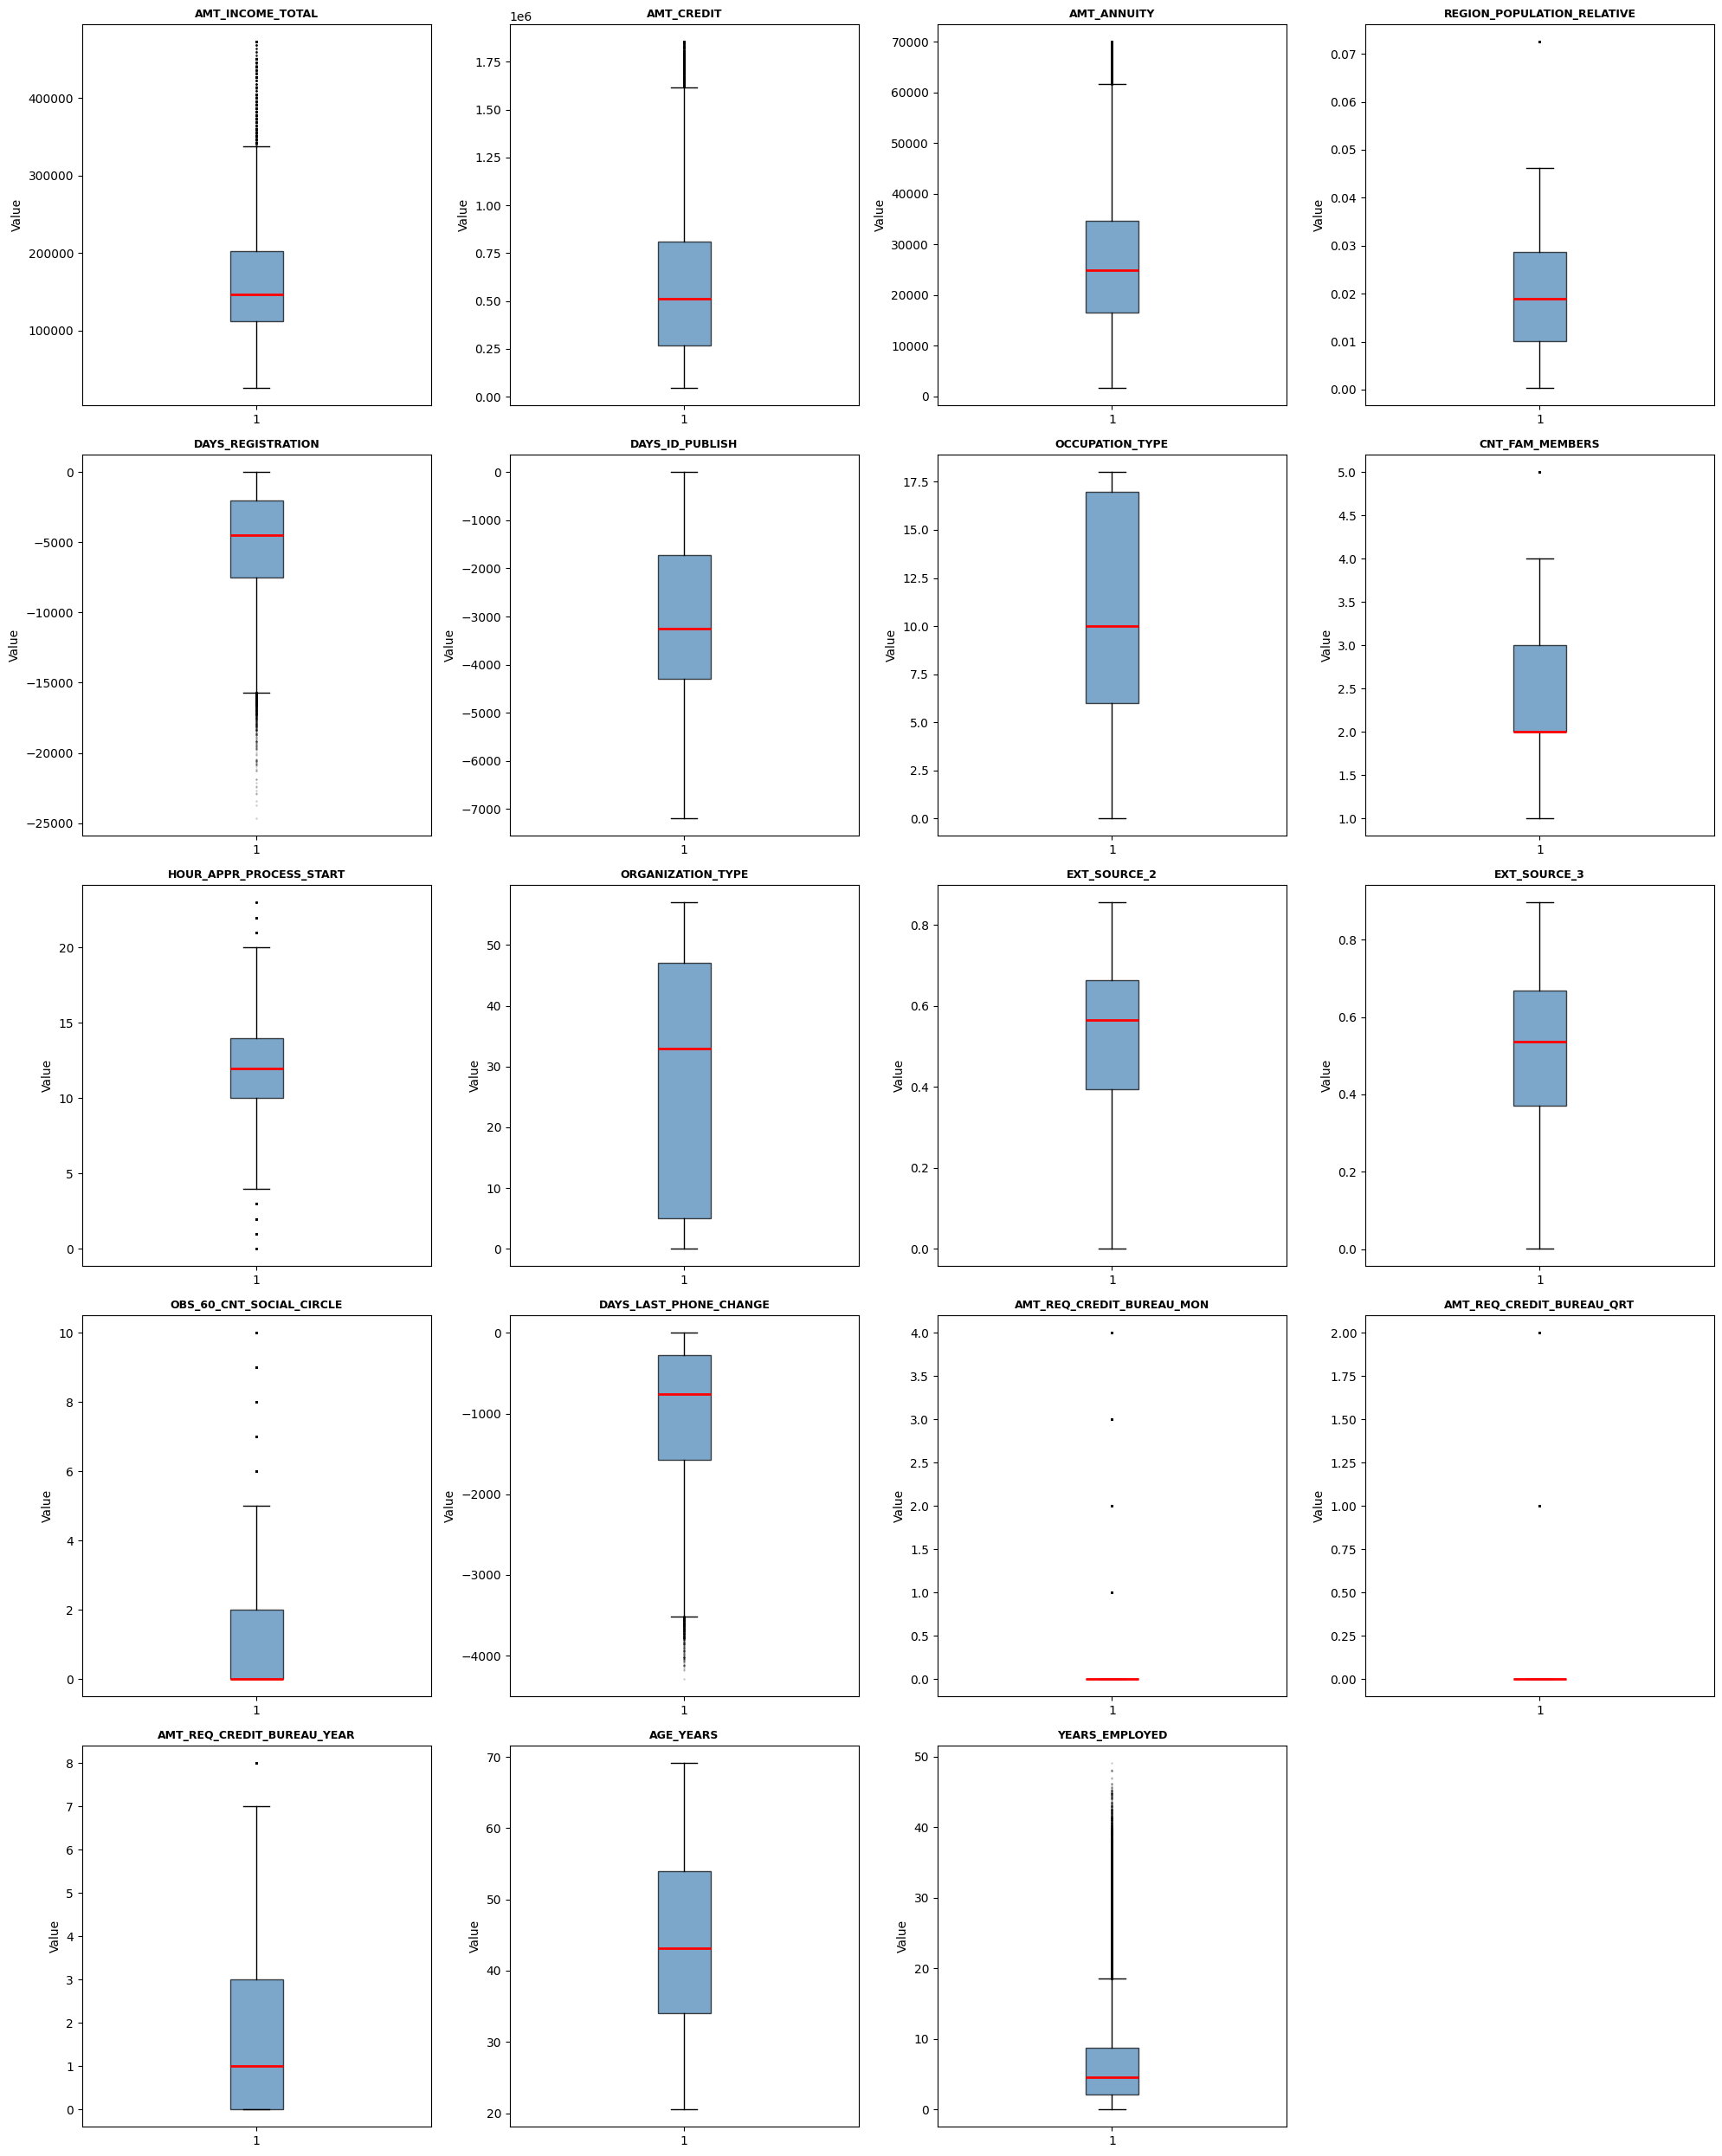

In [97]:
# new boxplots
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2),
                    flierprops=dict(marker=".", markersize=1, alpha=0.3))
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_ylabel("Value")

axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig("boxplots_after_capping.png", dpi=150)
plt.show()

In [109]:
df['YEARS_EMPLOYED'].describe()

count    252137.000000
mean          6.531971
std           6.406466
min           0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: YEARS_EMPLOYED, dtype: float64

#### Feature Engineering

These were some industry-standard features I found when googling common features used for risk analysis in financial institutions

In [132]:
# Create debt to income ratio
df["DEBT_TO_INCOME"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]

# Create annuity to income ratio
df["ANNUITY_TO_INCOME"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

# Create credit to annuity ratio
df["CREDIT_TO_ANNUITY"] = df["AMT_CREDIT"] / df["AMT_ANNUITY"]

# Age to employment ratio — how much of their life have they been working?
df["EMPLOYMENT_TO_AGE"] = df["YEARS_EMPLOYED"] / df["AGE_YEARS"]

# How recently did they change their ID? Maybe indicative on instability
df["ID_PUBLISH_ABS"] = df["DAYS_ID_PUBLISH"].abs()

# How long since they changed phone? Stability signal
df["PHONE_CHANGE_ABS"] = df["DAYS_LAST_PHONE_CHANGE"].abs()

# Total credit bureau inquiries across all time windows
df["TOTAL_BUREAU_INQUIRIES"] = (
    df["AMT_REQ_CREDIT_BUREAU_HOUR"] +
    df["AMT_REQ_CREDIT_BUREAU_DAY"] +
    df["AMT_REQ_CREDIT_BUREAU_WEEK"] +
    df["AMT_REQ_CREDIT_BUREAU_MON"] +
    df["AMT_REQ_CREDIT_BUREAU_QRT"] +
    df["AMT_REQ_CREDIT_BUREAU_YEAR"]
)

# Social circle default rate — what % of their social circle has defaulted?
df["SOCIAL_CIRCLE_DEFAULT_RATE"] = (
    df["DEF_60_CNT_SOCIAL_CIRCLE"] / 
    df["OBS_60_CNT_SOCIAL_CIRCLE"].replace(0, np.nan)
)

print(f"\nTotal features now: {df.shape[1]}")


Total features now: 92


### Preprocessing Summary

Data is now cleaned, encoded, and ready for modeling.

**Outlier Treatment:**
Capped 8 columns at their 99th percentile to remove extreme values that were
almost certainly data errors or would distort model training:

- `AMT_INCOME_TOTAL` | 472,500 | Max of 117M on a consumer loan is implausible
- `AMT_REQ_CREDIT_BUREAU_QRT` | 2 | 261 quarterly inquiries is almost certainly an error 
- `OBS_60_CNT_SOCIAL_CIRCLE` | 10 | 344 observed social circle members is implausible 
- `AMT_REQ_CREDIT_BUREAU_MON` | 4 | 27 monthly inquiries is extreme 
- `CNT_FAM_MEMBERS` | 5 | 20 family members is extreme 
- `AMT_ANNUITY` | 70,006 | Max annuity was 3.7x the 99th percentile 
- `AMT_REQ_CREDIT_BUREAU_YEAR` | 8 | 25 annual inquiries vs 99th percentile of 8 
- `AMT_CREDIT` | 1,854,000 | Max loan was 2.2x the 99th percentile 
- **`YEARS_EMPLOYED`** despite boxplot outliers —
49 years of employment is plausible for an older applicant and
represents real signal rather than an error. Did not cap

**Data Leakage Concern:**
In production system, cap values should be calculated only on training data and applied consistently to new incoming data. Calculating caps on the full
dataset leaks test set information into preprocessing decisions. For this analysis, I capped the full dataset but this distinction is important in production

**Missing Values:**
- Dropped 49 columns exceeding 40% missingness threshold
- Replaced sentinel value 365,243 in `DAYS_EMPLOYED` with NaN
- Filled bureau query columns with 0 (missing = no credit history)
- Filled `OCCUPATION_TYPE` with "Unknown"
- Filled small numerical missingness with median
- Filled small categorical missingness with mode
- Left `EXT_SOURCE_3` as NaN for XGBoost native handling

**Correlation & Redundancy:**
- Identified and dropped 10 highly correlated column pairs
- Kept the more meaningful or interpretable column from each pair

**Categorical Encoding:**
- Dropped `CODE_GENDER` for ethical/legal reasons
- Label encoded 6 high cardinality or binary columns
- One hot encoded 5 low cardinality columns, dropping the first to avoid the dummy variable trap

**Feature Engineering:**
- Created `AGE_YEARS` from `DAYS_BIRTH` (absolute value divided by 365)
- Created `YEARS_EMPLOYED` from `DAYS_EMPLOYED` (absolute value divided by 365)

**Feature Scaling:**
- Not applied globally — XGBoost and Random Forest are tree based models that are invariant to feature scale
- Logistic Regression requires scaling and will be handled separately in the modeling section

**Final Dataset:**
- Rows: 307,511
- Columns: 84
- Missing values: EXT_SOURCE_3 (~20%) and YEARS_EMPLOYED (~18%) left as NaN
  intentionally for XGBoost and Random Forest native handling
- All columns numerical — no categorical columns remain
- All extreme outliers treated or justified

**Next Step — Modeling:**
We will now train three models: Logistic Regression, Random Forest, and XGBoost.
Each will be evaluated using ROC-AUC score. The best performer will be used for
risk tiering and per-customer SHAP explainability analysis.

---

## Modeling

Here we evaluate three models and compare them

**Models used:**
1. **Logistic Regression** — linear model, baseline for credit scoring, highly interpretable
2. **Random Forest** — tree based ensemble using bagging (parallel trees)
3. **XGBoost** — tree based ensemble using boosting (sequential trees)

**Main Evaluation metric — ROC-AUC:**
We use ROC-AUC because dataset is imbalanced (91.93% non-default). A model that predicts no default every time would still have ~92%
accuracy while being completely useless. ROC-AUC measures how well the model separates defaulters from non-defaulters regardless of class balance

**ROC-AUC scoring:**
- 0.5 = random guessing
- 0.7 = acceptable
- 0.8 = good
- 0.9+ = excellent
- 1.0 = perfect

In [133]:
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training rows:   {len(X_train):,}")
print(f"Test rows:       {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")
print(f"Default rate (train): {y_train.mean():.2%}")
print(f"Default rate (test):  {y_test.mean():.2%}")

Training rows:   246,008
Test rows:       61,503
Features:        91
Default rate (train): 8.07%
Default rate (test):  8.07%


In [134]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Calculate class weight ratio for imbalance handling
# Used for XGBoost parameter
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print(f"Non-defaults: {neg:,}")
print(f"Defaults:     {pos:,}")
print(f"Scale ratio:  {scale:.2f}")

# Logistic Regression — needs imputation, scaling, and wrapped in a pipeline
lr_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale,
    eval_metric="auc",
    random_state=42
)

Non-defaults: 226,148
Defaults:     19,860
Scale ratio:  11.39


In [135]:
from sklearn.metrics import roc_auc_score
import time

results = {}

for name, model in [("Logistic Regression", lr_model), 
                     ("Random Forest", rf_model), 
                     ("XGBoost", xgb_model)]:
    
    print(f"Training {name}...")
    start = time.time()
    
    # train
    model.fit(X_train, y_train)
    
    # predict probabilities on test set
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Evaluate
    auc = roc_auc_score(y_test, y_prob)
    elapsed = time.time() - start
    
    results[name] = {
        "model": model,
        "y_prob": y_prob,
        "auc": auc
    }
    
    print(f"  ✅ AUC: {auc:.4f}  |  Time: {elapsed:.1f}s")
    print()

for name, res in results.items():
    print(f"{name:<25} AUC: {res['auc']:.4f}")

Training Logistic Regression...
  ✅ AUC: 0.7363  |  Time: 13.6s

Training Random Forest...
  ✅ AUC: 0.7369  |  Time: 35.4s

Training XGBoost...
  ✅ AUC: 0.7594  |  Time: 16.2s

Logistic Regression       AUC: 0.7363
Random Forest             AUC: 0.7369
XGBoost                   AUC: 0.7594


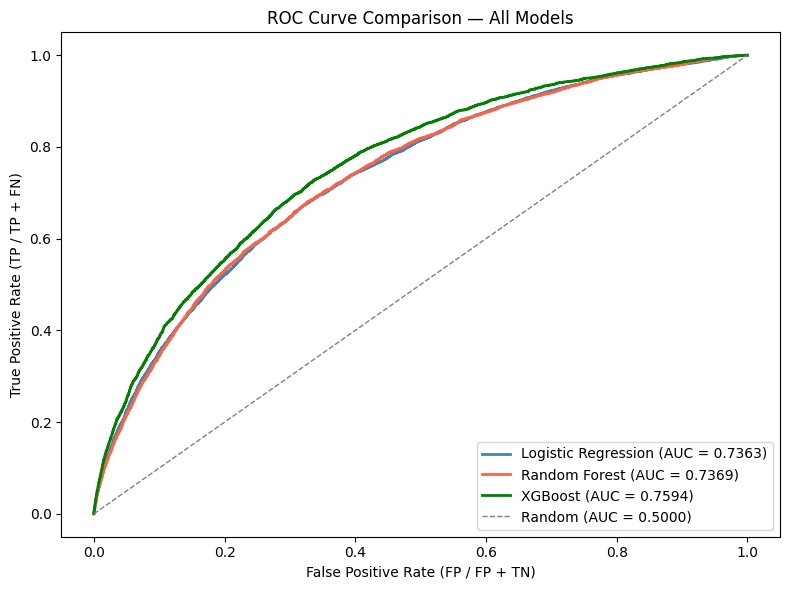

In [137]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

colors = ["steelblue", "tomato", "green"]

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name} (AUC = {res['auc']:.4f})")

# Random baseline
plt.plot([0, 1], [0, 1], color="gray", linewidth=1, 
         linestyle="--", label="Random (AUC = 0.5000)")

plt.xlabel("False Positive Rate (FP / FP + TN)")
plt.ylabel("True Positive Rate (TP / TP + FN)")
plt.title("ROC Curve Comparison — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

In [142]:
# Risk Tiering
# Get the best model's probability scores
best_model = results["XGBoost"]["model"]
y_prob_best = results["XGBoost"]["y_prob"]

# Define risk tier function
def assign_risk_tier(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

# Build results dataframe
results_df = X_test.copy()
results_df["DEFAULT_PROBABILITY"] = y_prob_best.round(4)
results_df["RISK_TIER"] = results_df["DEFAULT_PROBABILITY"].apply(assign_risk_tier)
results_df["ACTUAL_DEFAULT"] = y_test.values

print("Risk tier distribution:")
print(results_df["RISK_TIER"].value_counts())
print()
print("Default rate by risk tier:")
print(results_df.groupby("RISK_TIER")["ACTUAL_DEFAULT"].mean().round(4) * 100)
print()
print("Sample predictions:")
print(results_df[["DEFAULT_PROBABILITY", "RISK_TIER", "ACTUAL_DEFAULT"]].head(10))

# Save full predictions
results_df.to_csv("risk_predictions.csv")

Risk tier distribution:
RISK_TIER
Medium Risk    27639
Low Risk       21885
High Risk      11979
Name: count, dtype: int64

Default rate by risk tier:
RISK_TIER
High Risk      20.96
Low Risk        2.10
Medium Risk     7.21
Name: ACTUAL_DEFAULT, dtype: float64

Sample predictions:
            DEFAULT_PROBABILITY    RISK_TIER  ACTUAL_DEFAULT
SK_ID_CURR                                                  
396899                   0.2826     Low Risk               0
322041                   0.4349  Medium Risk               0
220127                   0.7216    High Risk               0
251531                   0.5005  Medium Risk               0
345558                   0.5965  Medium Risk               0
251419                   0.5502  Medium Risk               0
433604                   0.0838     Low Risk               0
268026                   0.0839     Low Risk               0
218614                   0.8428    High Risk               0
394494                   0.4762  Medium Risk   

              precision    recall  f1-score   support

  No Default       0.96      0.71      0.82     56538
     Default       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.77     61503



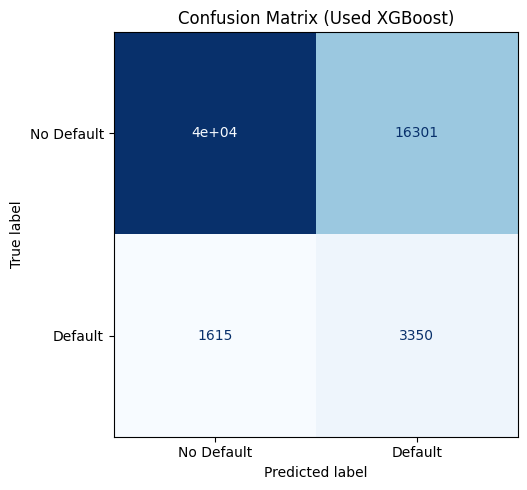

In [147]:
# MODEL EVALUATION — CONFUSION MATRIX & CLASSIFICATION REPORT
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Use 0.5 as classification threshold
y_pred = (y_prob_best >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix (Used XGBoost)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

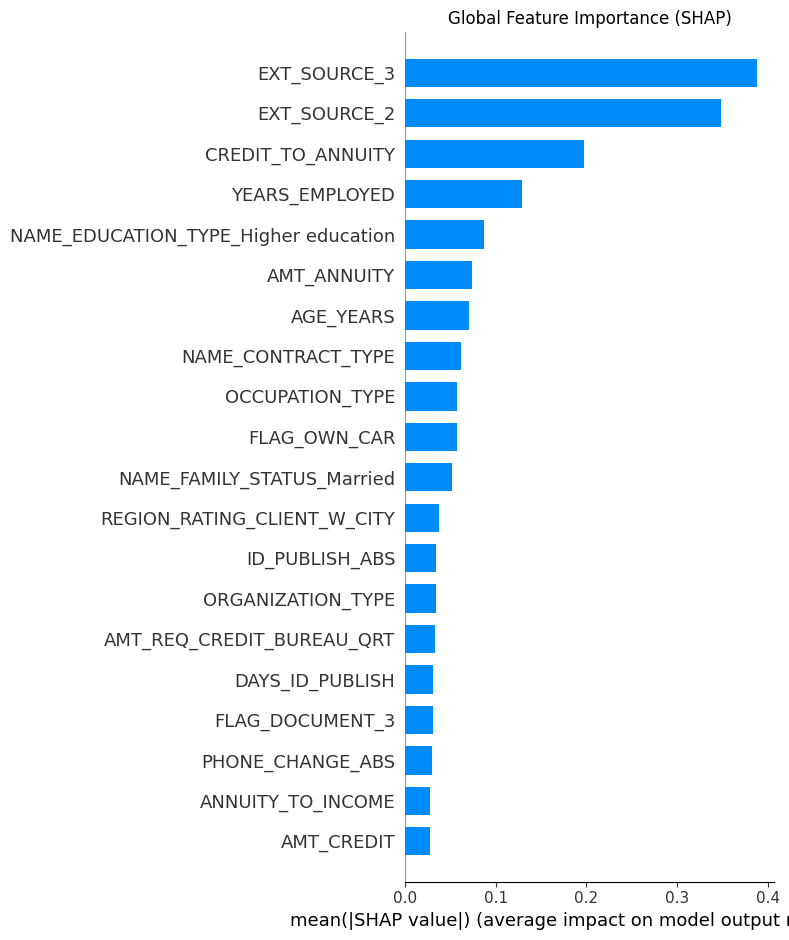

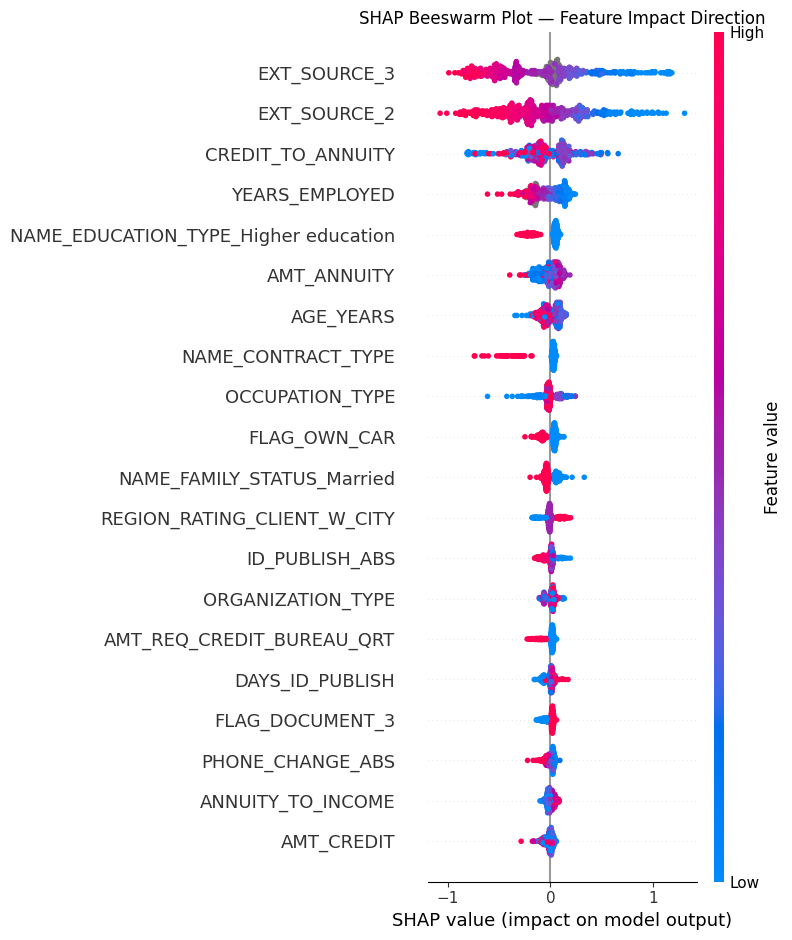

In [150]:
# SHAP - Which features matter most overall across all predictions?

# Build explainer using the trained XGBoost model
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values on a sample of test data (500 rows for speed)
X_test_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Global feature importance bar plot
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Beeswarm plot — shows direction of impact for each feature
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Beeswarm Plot — Feature Impact Direction")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

Finding example customers from each risk tier...

--- LOW RISK CUSTOMER ---

  CUSTOMER #0
  Risk Tier:          Low Risk
  Default Probability: 28.26%
  Actual Default:     NO ✅

  Top feature values:
    NAME_CONTRACT_TYPE                            0.0000
    FLAG_OWN_CAR                                  1.0000
    FLAG_OWN_REALTY                               1.0000
    AMT_INCOME_TOTAL                              157500.0000
    AMT_CREDIT                                    770292.0000
    AMT_ANNUITY                                   30676.5000
    REGION_POPULATION_RELATIVE                    0.0101
    DAYS_REGISTRATION                             -2876.0000
    DAYS_ID_PUBLISH                               -4402.0000
    FLAG_MOBIL                                    1.0000
    FLAG_WORK_PHONE                               0.0000
    FLAG_CONT_MOBILE                              1.0000
    FLAG_PHONE                                    0.0000
    FLAG_EMAIL                     

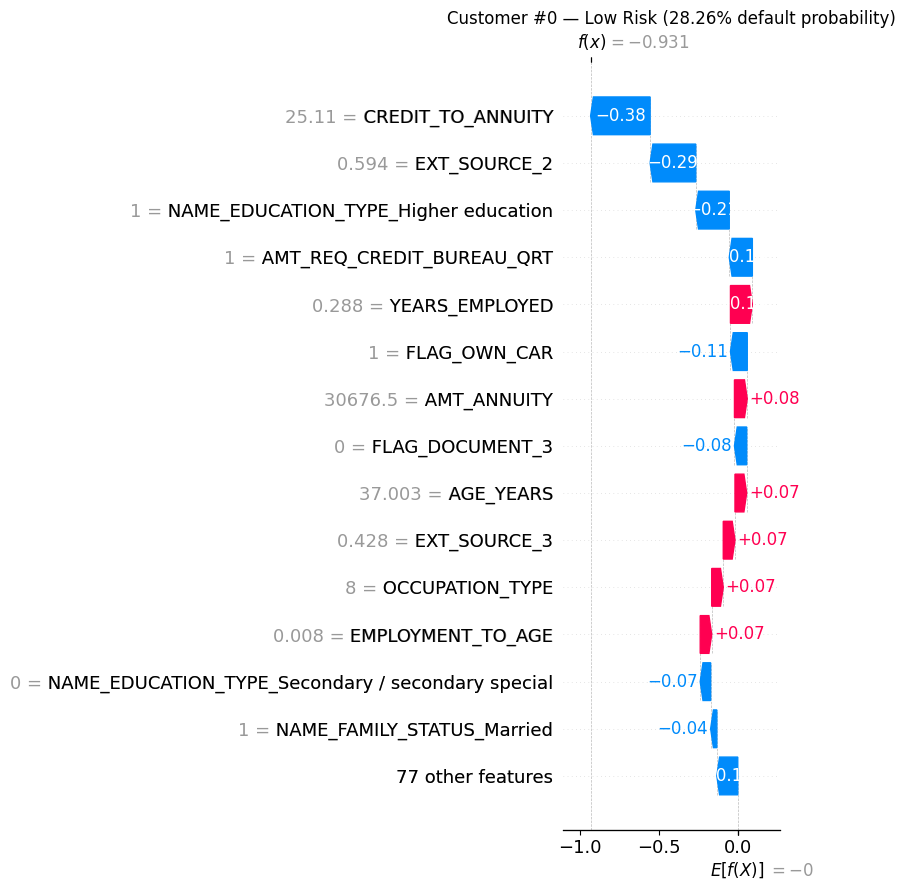


  Waterfall plot saved as shap_customer_0.png

--- MEDIUM RISK CUSTOMER ---

  CUSTOMER #1
  Risk Tier:          Medium Risk
  Default Probability: 43.49%
  Actual Default:     NO ✅

  Top feature values:
    NAME_CONTRACT_TYPE                            0.0000
    FLAG_OWN_CAR                                  0.0000
    FLAG_OWN_REALTY                               0.0000
    AMT_INCOME_TOTAL                              90000.0000
    AMT_CREDIT                                    364896.0000
    AMT_ANNUITY                                   19926.0000
    REGION_POPULATION_RELATIVE                    0.0073
    DAYS_REGISTRATION                             -4654.0000
    DAYS_ID_PUBLISH                               -1259.0000
    FLAG_MOBIL                                    1.0000
    FLAG_WORK_PHONE                               0.0000
    FLAG_CONT_MOBILE                              1.0000
    FLAG_PHONE                                    0.0000
    FLAG_EMAIL                  

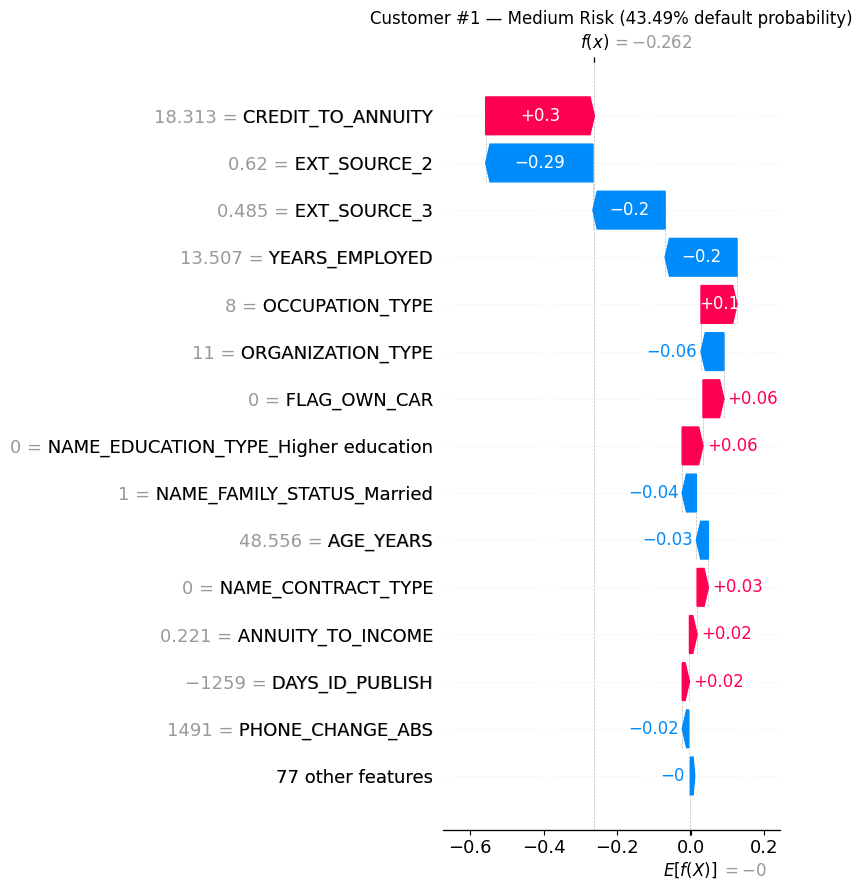


  Waterfall plot saved as shap_customer_1.png

--- HIGH RISK CUSTOMER ---

  CUSTOMER #2
  Risk Tier:          High Risk
  Default Probability: 72.16%
  Actual Default:     NO ✅

  Top feature values:
    NAME_CONTRACT_TYPE                            0.0000
    FLAG_OWN_CAR                                  0.0000
    FLAG_OWN_REALTY                               1.0000
    AMT_INCOME_TOTAL                              148500.0000
    AMT_CREDIT                                    284400.0000
    AMT_ANNUITY                                   18643.5000
    REGION_POPULATION_RELATIVE                    0.0145
    DAYS_REGISTRATION                             -12511.0000
    DAYS_ID_PUBLISH                               -2474.0000
    FLAG_MOBIL                                    1.0000
    FLAG_WORK_PHONE                               0.0000
    FLAG_CONT_MOBILE                              1.0000
    FLAG_PHONE                                    1.0000
    FLAG_EMAIL                    

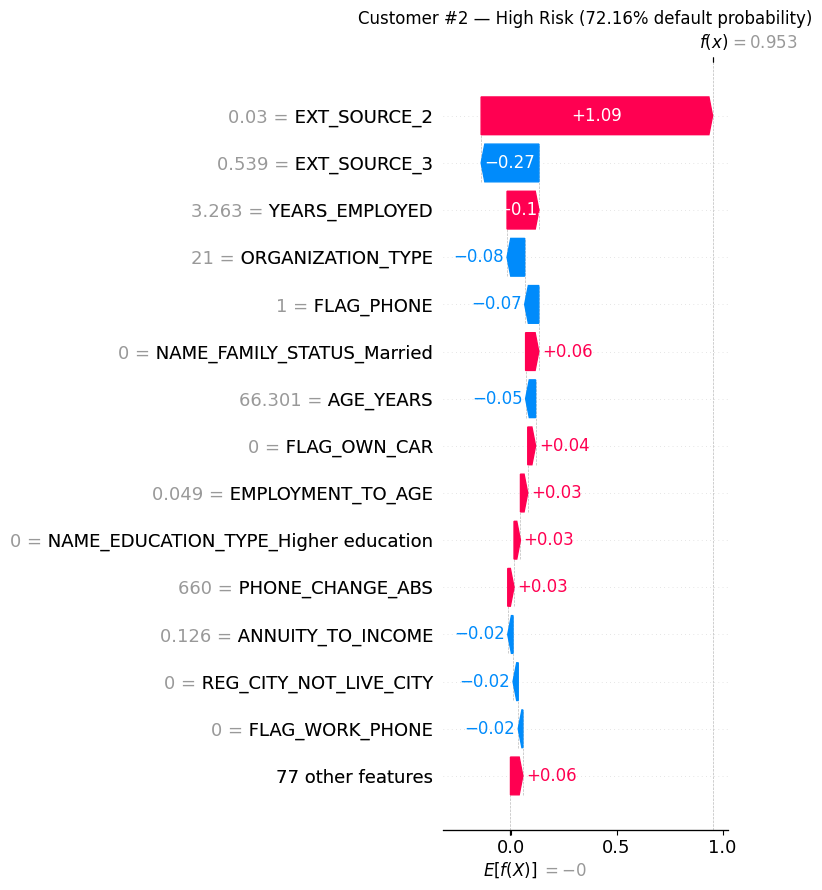


  Waterfall plot saved as shap_customer_2.png


{'customer_index': 2,
 'probability': np.float32(0.7216394),
 'risk_tier': 'High Risk',
 'actual_default': np.int64(0)}

In [152]:
# SHAP — PER CUSTOMER
# For any individual customer, show what drove their risk score and by how much
# Full explanation for a single customer, index is integer position in X_test
# Shows risk tier and default probability, actual outcome, feature values for this customer, and SHAP waterfall plot showing what drove the decision
def explain_customer(customer_index):
    
    # Get customer data
    customer = X_test.iloc[[customer_index]]
    prob = best_model.predict_proba(customer)[0][1]
    tier = assign_risk_tier(prob)
    actual = y_test.iloc[customer_index]
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"  CUSTOMER #{customer_index}")
    print(f"{'='*60}")
    print(f"  Risk Tier:          {tier}")
    print(f"  Default Probability: {prob:.2%}")
    print(f"  Actual Default:     {'YES ⚠️' if actual == 1 else 'NO ✅'}")
    print(f"{'='*60}")
    
    # Top feature values for this customer
    print(f"\n  Top feature values:")
    customer_series = X_test.iloc[customer_index]
    for feat, val in customer_series.items():
        print(f"    {feat:<45} {val:.4f}")
    
    # SHAP waterfall plot
    shap_vals_customer = explainer.shap_values(customer)
    
    explanation = shap.Explanation(
        values=shap_vals_customer[0],
        base_values=explainer.expected_value,
        data=customer.iloc[0],
        feature_names=X_test.columns.tolist()
    )
    
    shap.waterfall_plot(explanation, show=False, max_display=15)
    plt.title(f"Customer #{customer_index} — {tier} ({prob:.2%} default probability)")
    plt.tight_layout()
    plt.savefig(f"shap_customer_{customer_index}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Waterfall plot saved as shap_customer_{customer_index}.png")
    
    return {
        "customer_index": customer_index,
        "probability": prob,
        "risk_tier": tier,
        "actual_default": actual
    }


# Run explanation for one customer from each risk tier
print("Finding example customers from each risk tier...")

low_risk_idx = results_df[results_df["RISK_TIER"] == "Low Risk"].index[0]
med_risk_idx = results_df[results_df["RISK_TIER"] == "Medium Risk"].index[0]
high_risk_idx = results_df[results_df["RISK_TIER"] == "High Risk"].index[0]

# Convert index to integer position in X_test
low_pos = X_test.index.get_loc(low_risk_idx)
med_pos = X_test.index.get_loc(med_risk_idx)
high_pos = X_test.index.get_loc(high_risk_idx)

print("\n--- LOW RISK CUSTOMER ---")
explain_customer(low_pos)

print("\n--- MEDIUM RISK CUSTOMER ---")
explain_customer(med_pos)

print("\n--- HIGH RISK CUSTOMER ---")
explain_customer(high_pos)

## Risk Tiering, Evaluation & Explainability

### Risk Tiering
XGBoost's raw probability output is converted into three actionable risk bands:
- 🟢 **Low Risk** — probability < 30%: recommend approval
- 🟡 **Medium Risk** — probability 30-60%: recommend manual review
- 🔴 **High Risk** — probability > 60%: recommend decline

### Model Evaluation
The model is evaluated using ROC-AUC rather than accuracy due to class imbalance.
XGBoost achieved the highest AUC of 0.7594, outperforming
Logistic Regression (0.7363) and Random Forest (0.7369).

### Explainability — SHAP
SHAP is used to make the model interpretable at two levels:

**Global level** — which features drive predictions across all customers?
The summary and beeswarm plots show overall feature importance and the
direction of each feature's impact on default probability

**Individual level** — what drove this specific customer's score?
The waterfall plot for any customer shows exactly which features pushed
their probability up or down and by how much, starting from the base rate

This per-customer explainability is likely very useful in financial services where applicants want to know why
they were denied a loan